# Ноутбук 03: Генерация текста (русскоязычный вариант)

**Цель:** показать, как параметры генерации влияют на стиль, разнообразие и повторы в русскоязычных текстах.

**Модель:** `sberbank-ai/rugpt3small_based_on_gpt2`.

- вместо английского GPT-2 использована русскоязычная генеративная модель;
- все промпты переведены и адаптированы;
- добавлены количественные показатели:
- lexical diversity,
- bigram repeat ratio;
- есть таблицы, графики и сравнение режимов;
- добавлена проверка разнообразия при повторных запусках


In [1]:
import random
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from huggingface_hub.utils import disable_progress_bars

disable_progress_bars()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_id = 'sberbank-ai/rugpt3small_based_on_gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
model.eval()
model.to(device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print('Модель генерации загружена!')
print('model_id:', model_id)
print('device:', device)


c:\anacon\envs\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 149/149 [00:00<00:00, 14892.56it/s]
The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель генерации загружена!
model_id: sberbank-ai/rugpt3small_based_on_gpt2
device: cuda


In [2]:
def clean_text(text: str) -> str:
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def lexical_diversity(text: str) -> float:
    words = [w.strip(string.punctuation + "«»—…").lower() for w in text.split()]
    words = [w for w in words if w]
    return len(set(words)) / len(words) if words else 0.0


def bigram_repeat_ratio(text: str) -> float:
    words = [w.strip(string.punctuation + "«»—…").lower() for w in text.split()]
    words = [w for w in words if w]
    if len(words) < 2:
        return 0.0
    bigrams = list(zip(words[:-1], words[1:]))
    return 1 - len(set(bigrams)) / len(bigrams)


def generate_text(prompt: str, max_new_tokens: int = 45, **generation_kwargs) -> str:
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    kwargs = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.eos_token_id,
        **generation_kwargs,
    }
    with torch.no_grad():
        output_ids = model.generate(**inputs, **kwargs)
    text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return clean_text(text)



## Шаг 1: Базовая генерация

Сравним `greedy` и `sampling` на одном русском промпте.


In [3]:
prompt = 'В ближайшие пять лет большие языковые модели будут'

greedy_text = generate_text(prompt, do_sample=False, max_new_tokens=45)
sampled_text = generate_text(prompt, do_sample=True, temperature=0.9, top_p=0.92, max_new_tokens=45)

print('Промпт:')
print(prompt)
print()
print('--- Жадный режим ---')
print(greedy_text)
print()
print('--- Сэмплирование ---')
print(sampled_text)



Промпт:
В ближайшие пять лет большие языковые модели будут

--- Жадный режим ---
В ближайшие пять лет большие языковые модели будут развиваться в направлении развития разговорного языка. В этом году в рамках проекта "Слово и культура" планируется провести ряд мероприятий, направленных на развитие разговорного языка. В частности, в рамках проекта "Слово и культура

--- Сэмплирование ---
В ближайшие пять лет большие языковые модели будут заменяться на традиционные. И так: - Существующие языковые модели, прежде всего, будут интегрированы в более современные языки, ориентированные на русский, испанский, китайский, японский; - На практике будет


## Шаг 2: Влияние температуры

Оцениваем баланс между разнообразием и устойчивостью при разных `temperature`.


,temperature,word_count,lexical_diversity,bigram_repeat_ratio
0,0.6,29,0.827586,0.107143
1,0.9,4,1.000000,0.000000
2,1.2,29,1.000000,0.000000


temperature=0.6
бы они могли решать любые проблемы с помощью нейронных сетей. С помощью нейронных сетей человек может управлять своими эмоциями, чувствами, мыслями, мыслями других людей, а также другими процессами в

temperature=0.9
бы чувствовать себя комфортно.

temperature=1.2
-либо изменить к лучшему в будущем... А ещё, эта музыка очень нравится тем, кто ищет для себя что-то новое. Сегодня я предлагаю Вам послушать новую песенку, которая рассказывает нам



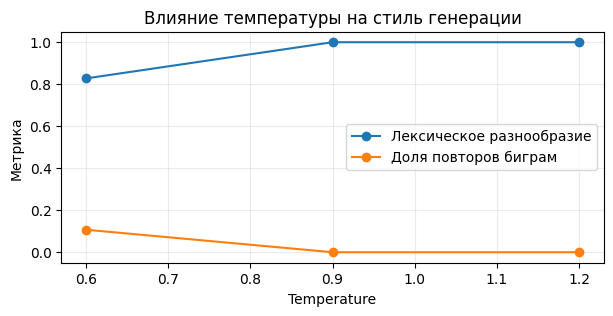

In [4]:
prompt = 'Современные нейросети помогают людям в том, что'
temperatures = [0.6, 0.9, 1.2]

rows = []
for temp in temperatures:
    text = generate_text(
        prompt,
        do_sample=True,
        temperature=temp,
        top_p=0.92,
        max_new_tokens=40,
    )
    continuation = clean_text(text[len(prompt):])
    rows.append(
        {
            'temperature': temp,
            'continuation': continuation,
            'word_count': len(continuation.split()),
            'lexical_diversity': lexical_diversity(continuation),
            'bigram_repeat_ratio': bigram_repeat_ratio(continuation),
        }
    )

temp_df = pd.DataFrame(rows)
display(temp_df[['temperature', 'word_count', 'lexical_diversity', 'bigram_repeat_ratio']])

for _, row in temp_df.iterrows():
    print(f"temperature={row['temperature']}")
    print(row['continuation'])
    print()

plt.figure(figsize=(7, 3))
plt.plot(temp_df['temperature'], temp_df['lexical_diversity'], marker='o', label='Лексическое разнообразие')
plt.plot(temp_df['temperature'], temp_df['bigram_repeat_ratio'], marker='o', label='Доля повторов биграм')
plt.xlabel('Temperature')
plt.ylabel('Метрика')
plt.title('Влияние температуры на стиль генерации')
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## Шаг 3: Top-K и Top-P

Сравниваем стратегии ограничения пространства кандидатов.


In [5]:
prompt = 'В небольшом научном центре однажды обнаружили, что'

configs = [
    {'mode': 'Top-K=20', 'kwargs': {'do_sample': True, 'top_k': 20, 'top_p': 1.0, 'temperature': 0.9}},
    {'mode': 'Top-P=0.90', 'kwargs': {'do_sample': True, 'top_k': 0, 'top_p': 0.90, 'temperature': 0.9}},
    {'mode': 'Top-P=0.95', 'kwargs': {'do_sample': True, 'top_k': 0, 'top_p': 0.95, 'temperature': 0.9}},
]

rows = []
for cfg in configs:
    text = generate_text(prompt, max_new_tokens=40, **cfg['kwargs'])
    continuation = clean_text(text[len(prompt):])
    rows.append(
        {
            'mode': cfg['mode'],
            'continuation': continuation,
            'word_count': len(continuation.split()),
            'lexical_diversity': lexical_diversity(continuation),
        }
    )

sampling_df = pd.DataFrame(rows)
display(sampling_df[['mode', 'word_count', 'lexical_diversity']])

for _, row in sampling_df.iterrows():
    print(row['mode'])
    print(row['continuation'])
    print()


,mode,word_count,lexical_diversity
0,Top-K=20,22,1.000000
1,Top-P=0.90,28,0.857143
2,Top-P=0.95,24,0.958333


Top-K=20
в каждой клетке — от 5 до 20 тысяч маленьких клеток, и что, несмотря на свой возраст, они могут содержать миллионы бактерий.

Top-P=0.90
при комнатной температуре свет может сильно рассеиваться. Это открытие впервые было сделано в 1956 году. Ученые создали новый способ фильтрации света при комнатной температуре. Согласно исследованиям, при комна

Top-P=0.95
гены (специфические для мужчин) сходны с мужской, они настолько сходны по строению (имеют то же строение и структуру), что наличие двух генов (фактора гормона



## Шаг 4: Beam Search vs Sampling

Покажем разницу между оптимизацией вероятности (`beam`) и генерацией разнообразия (`sampling`).


In [6]:
prompt = 'Лучший способ научиться программированию — это'

beam_text = generate_text(
    prompt,
    do_sample=False,
    num_beams=5,
    no_repeat_ngram_size=2,
    early_stopping=True,
    max_new_tokens=40,
)

sample_text = generate_text(
    prompt,
    do_sample=True,
    temperature=0.95,
    top_p=0.92,
    max_new_tokens=40,
)

compare_df = pd.DataFrame(
    [
        {'mode': 'Beam Search', 'text': clean_text(beam_text[len(prompt):])},
        {'mode': 'Sampling', 'text': clean_text(sample_text[len(prompt):])},
    ]
)

compare_df['word_count'] = compare_df['text'].str.split().str.len()
compare_df['lexical_diversity'] = compare_df['text'].apply(lexical_diversity)
compare_df['bigram_repeat_ratio'] = compare_df['text'].apply(bigram_repeat_ratio)

display(compare_df[['mode', 'word_count', 'lexical_diversity', 'bigram_repeat_ratio']])

for _, row in compare_df.iterrows():
    print(row['mode'])
    print(row['text'])
    print()


,mode,word_count,lexical_diversity,bigram_repeat_ratio
0,Beam Search,29,0.814815,0.0
1,Sampling,30,0.900000,0.0


Beam Search
учиться на чужих ошибках, а не на своих собственных. — И что же это за ошибки? — спросил я, когда мы вышли на улицу. Я не знал, что ответить

Sampling
изучение языков программирования. Однако не все программисты в состоянии освоить язык Python. Некоторые из них хотят, чтобы у них была возможность изучить этот язык. В этой статье я расскажу вам



## Шаг 5: Практический пример — описания продуктов

Простой шаблон генератора маркетинговых описаний на русском.


In [7]:
product_prompts = [
    'Товар: беспроводные наушники. Характеристики: шумоподавление, 30 часов работы, быстрая зарядка. Описание:',
    'Товар: робот-пылесос. Характеристики: влажная уборка, построение карты квартиры, управление через приложение. Описание:',
]

for prompt in product_prompts:
    text = generate_text(
        prompt,
        do_sample=True,
        temperature=0.85,
        top_p=0.9,
        repetition_penalty=1.15,
        max_new_tokens=55,
    )
    print(text)
    print()


Товар: беспроводные наушники. Характеристики: шумоподавление, 30 часов работы, быстрая зарядка. Описание: В ассортименте фирмы – Bluetooth, USB 2.0 и Wi-Fi, 3G, LTE, CD/MP3 плеер и т.д. Отличительные особенности - компактный размер (8 х 9 см) и удобная форма для переноски.

Товар: робот-пылесос. Характеристики: влажная уборка, построение карты квартиры, управление через приложение. Описание: Программа для уборки помещений с помощью пылесоса Homestead позволяет избавиться от пыли и мусора на кухне или ванной комнате. В состав этого устройства входят два типа пылесосов - механические и электрические (электромагнитные). В зависимости от того, какая модель пылесоса вам



## Шаг 6: Проверка разнообразия при повторных запусках

Считаем число уникальных ответов в `greedy` и в `sampling`.


In [8]:
prompt = 'Если компания внедряет LLM в продукт, то ей важно'

greedy_runs = [generate_text(prompt, do_sample=False, max_new_tokens=35) for _ in range(3)]
sampled_runs = [generate_text(prompt, do_sample=True, temperature=0.9, top_p=0.92, max_new_tokens=35) for _ in range(4)]

print(f'Greedy: уникальных ответов {len(set(greedy_runs))} из 3')
print(f'Sampling: уникальных ответов {len(set(sampled_runs))} из 4')

print()
print('Примеры Sampling:')
for i, text in enumerate(sampled_runs, 1):
    print(f'Вариант {i}: {text}')
    print()



Greedy: уникальных ответов 1 из 3
Sampling: уникальных ответов 4 из 4

Примеры Sampling:
Вариант 1: Если компания внедряет LLM в продукт, то ей важно, чтобы у потребителя были четкие представления о том, как работает продукт. Если продукт будет в том или ином виде реализован в конкретном приложении, то его нужно будет поддерживать

Вариант 2: Если компания внедряет LLM в продукт, то ей важно, чтобы клиенты видели в компании LLM производителя. При этом, компания должна учесть, что многие компании ограничиваются установкой LLM в рамках одного продукта. Поэтому

Вариант 3: Если компания внедряет LLM в продукт, то ей важно, чтобы это было выгодно самой компании. В противном случае она просто потерпит убытки. Если компания внедряет LLM в продукт, то ей важно, чтобы это было выгодно

Вариант 4: Если компания внедряет LLM в продукт, то ей важно определить соответствие продуктов требованиям заказчиков, и, в частности, обеспечить соответствие продукции их качествам. Это необходимо для того, что

In [9]:
params = pd.DataFrame(
    [
        ('max_new_tokens', 'Сколько новых токенов добавить'),
        ('do_sample', 'False = детерминированно, True = вероятностная генерация'),
        ('temperature', 'Регулирует креативность и риск шумов'),
        ('top_k', 'Ограничение по K наиболее вероятным токенам'),
        ('top_p', 'Nucleus sampling по накопленной вероятности'),
        ('num_beams', 'Число лучей в beam search'),
        ('repetition_penalty', 'Штраф за повторение фраз'),
    ],
    columns=['Параметр', 'Назначение'],
)

print('Справочник ключевых параметров генерации:')
display(params)


Справочник ключевых параметров генерации:


,Параметр,Назначение
0,max_new_tokens,Сколько новых токенов добавить
1,do_sample,"False = детерминированно, True = вероятностная..."
2,temperature,Регулирует креативность и риск шумов
3,top_k,Ограничение по K наиболее вероятным токенам
4,top_p,Nucleus sampling по накопленной вероятности
5,num_beams,Число лучей в beam search
6,repetition_penalty,Штраф за повторение фраз
